## Gold price predict Using Decision Tree Regressor

## Problem Statement
The objective of this project is to predict the closing price of gold using historical market data such as open, high, low prices, volume, and date-based features. By applying a Decision Tree Regressor, the model aims to capture patterns and relationships in price movements. This helps in understanding market trends and improving decision-making in financial analysis.

### Steps to be followed:
1. Importing the required Libraries
2. Loading the dataset
3. Data Preprocessing
4. Checking Null values
5. Data Wrangling (Filling Null values)
6. Data Visualization
7. Machine Learning
8. Features Seletion
9. Train-Test Split
10. Model Training
11. Model Predtion
12. Training Score
13. Testing Score
14. r2 score
15. mse /rmse 
16. GridSearch

## Import library 

In [65]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error


## Loading the Dataset

In [66]:
df=pd.read_csv(r"C:\Users\Admin\Downloads\GoldUSD.csv")
df

,Date,Open,High,Low,Close,Volume
0,30-08-00,273.899994,273.899994,273.899994,273.899994,0
1,31-08-00,274.799988,278.299988,274.799988,278.299988,0
2,01-09-00,277.000000,277.000000,277.000000,277.000000,0
3,05-09-00,275.799988,275.799988,275.799988,275.799988,2
4,06-09-00,274.200012,274.200012,274.200012,274.200012,0
...,...,...,...,...,...,...
6394,25-02-26,5166.000000,5206.399902,5166.000000,5206.399902,1772
6395,26-02-26,5177.200195,5199.200195,5143.899902,5176.500000,1520
6396,27-02-26,5186.700195,5280.000000,5176.700195,5230.500000,354
6397,02-03-26,5346.600098,5405.000000,5266.299805,5294.399902,354


## Data Preprocessing

In [67]:
df.shape

(6399, 6)

In [68]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

In [69]:
df.head()

,Date,Open,High,Low,Close,Volume
0,30-08-00,273.899994,273.899994,273.899994,273.899994,0
1,31-08-00,274.799988,278.299988,274.799988,278.299988,0
2,01-09-00,277.000000,277.000000,277.000000,277.000000,0
3,05-09-00,275.799988,275.799988,275.799988,275.799988,2
4,06-09-00,274.200012,274.200012,274.200012,274.200012,0


In [70]:
df.tail()

,Date,Open,High,Low,Close,Volume
6394,25-02-26,5166.000000,5206.399902,5166.000000,5206.399902,1772
6395,26-02-26,5177.200195,5199.200195,5143.899902,5176.500000,1520
6396,27-02-26,5186.700195,5280.000000,5176.700195,5230.500000,354
6397,02-03-26,5346.600098,5405.000000,5266.299805,5294.399902,354
6398,03-03-26,5335.700195,5394.200195,5334.899902,5377.299805,21189


In [71]:
df.duplicated().sum()

np.int64(0)

In [72]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [73]:
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\Admin\AppData\Local\Temp\ipykernel_20384\2394721818.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [74]:
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['day_of_week'] = df['Date'].dt.dayofweek

## Data Visualization

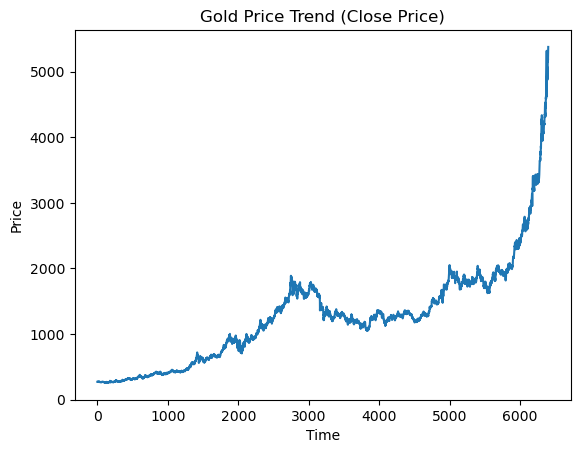

In [75]:
plt.figure()
plt.plot(df['Close'])
plt.title("Gold Price Trend (Close Price)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

## Observation:
The line plot shows the trend of gold prices over time, highlighting fluctuations and overall market movement.

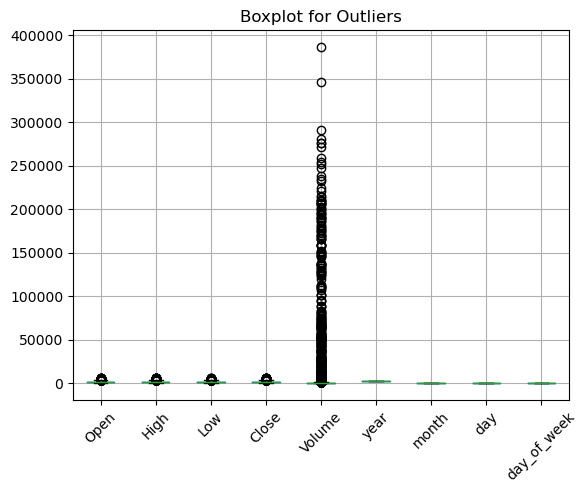

In [76]:
plt.figure()
df.boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot for Outliers")
plt.show()

## Observation:
The boxplot helps identify outliers and shows the spread and distribution of numerical features in the dataset

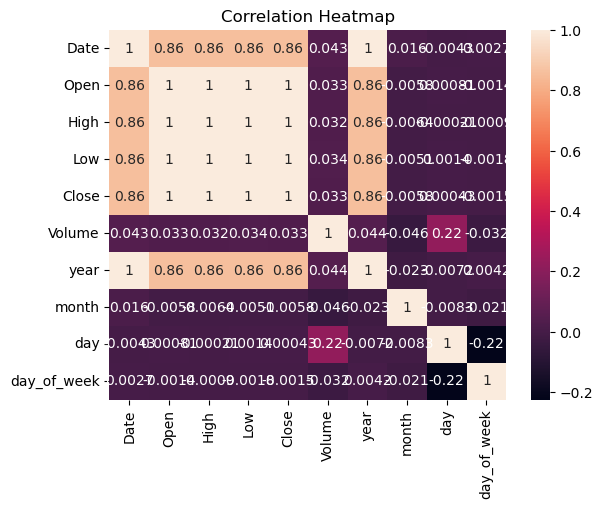

In [77]:
plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

## Observation:
Price-related features are highly correlated, indicating strong relationships, while volume has weaker influence

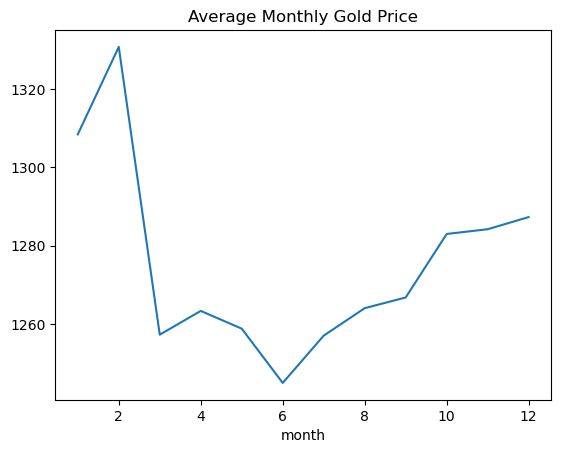

In [78]:
plt.figure()
df.groupby('month')['Close'].mean().plot()
plt.title("Average Monthly Gold Price")
plt.show()

## Observation:
The monthly trend shows variation in gold prices across months, indicating possible seasonal patterns.

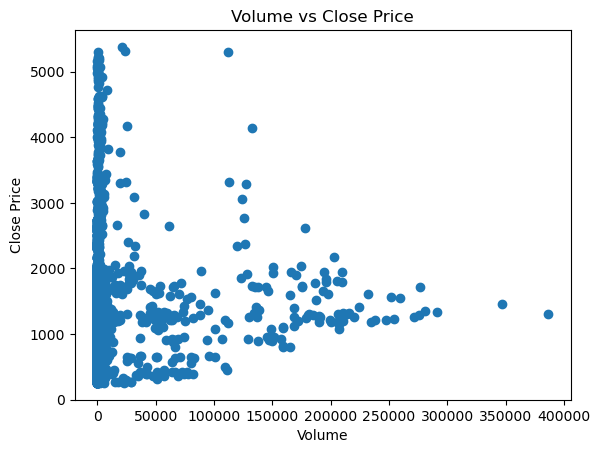

In [79]:
plt.figure()
plt.scatter(df['Volume'], df['Close'])
plt.xlabel("Volume")
plt.ylabel("Close Price")
plt.title("Volume vs Close Price")
plt.show()

## Observation:
Volume shows weak or no clear relationship with closing price, indicating it is not a strong predictor

## Feature Selection (x, y)

In [80]:
X = df[['Open', 'High', 'Low', 'Volume', 'year', 'month', 'day']]
y = df['Close']

## Train-Test Split

In [81]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Training

In [84]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

model.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

## Model Prediction

In [85]:
y_pred = model.predict(x_test)

## R2 Score

In [86]:
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.998145550051534


## Mse / Rmse

In [87]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 34.708959530672324


## GridSearchCV

In [88]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(DecisionTreeRegressor(), param_grid, cv=5)
grid.fit(x_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}


## Training score

In [89]:
model.score(x_train, y_train)

0.998231214171048

## Testing Score

In [90]:
 model.score(x_test, y_test)

0.998145550051534

In [91]:
model = DecisionTreeRegressor(max_depth=5, min_samples_leaf=5)